In [2]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from data_cleaning import stats, standardization

## standardize the input data for clustering
see p. 52 MACHINE LEARNING FOR
ASSET MANAGERS
Marcos M. López de Prado

In [ ]:
df = pd.read_csv('data/final_final_df.csv')

df = df.drop(columns=['postTransactionAmounts.sharesOwnedFollowingTransaction'])
df.columns

,Unnamed: 0.2,Unnamed: 0.1,issuer.name,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,...,direct_ownership,transaction_month,month_sin,month_cos,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,cluster_buy,holding_change_percent,high_change_in_holdings
0,0,0,PHAZAR CORP,ANTP,INZER DEBORAH,2009-01-29,1000.0,2.5000,D,False,...,1,1,5.000000e-01,0.866025,1,0,2.0,1,50.000000,1
1,1,1,BlackRock Inc.,BLK,MERRILL LYNCH CO INC,2009-01-22,1000.0,106.0499,D,False,...,1,1,5.000000e-01,0.866025,5,0,5.0,1,0.042892,0
2,2,2,HORIZON BANCORP /IN/,HBNC,NEFF JAMES D,2009-01-30,6000.0,12.5000,D,False,...,1,1,5.000000e-01,0.866025,19,0,3.0,1,16.348774,1
3,3,3,HORIZON BANCORP /IN/,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,...,1,1,5.000000e-01,0.866025,19,0,3.0,1,9.367681,1
4,4,4,WILLIS LEASE FINANCE CORP,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,...,0,1,5.000000e-01,0.866025,21,0,3.0,1,0.290388,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239414,239737,239737,Texas Pacific Land Corp,TPL,STAHL MURRAY,2023-12-29,3.0,1572.4500,I,True,...,0,12,-2.449294e-16,1.000000,5352,1,53.0,1,0.001511,0
239415,239738,239738,"NB Bancorp, Inc.",NBBK,AYOUB PAUL J,2023-12-28,5000.0,14.0000,I,True,...,0,12,-2.449294e-16,1.000000,1,0,4.0,1,0.000000,0
239416,239739,239739,BLACKROCK MUNIYIELD PENNSYLVANIA QUALITY FUND,MPA,SABA CAPITAL MANAGEMENT LP,2023-12-28,2064.0,11.5700,I,False,...,0,12,-2.449294e-16,1.000000,1311,1,2.0,1,0.108754,0
239417,239740,239740,BlackRock ESG Capital Allocation Term Trust,ECAT,SABA CAPITAL MANAGEMENT LP,2023-12-28,299702.0,16.3700,I,False,...,0,12,-2.449294e-16,1.000000,1311,1,9.0,1,1.263882,1


In [10]:
df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'issuer.name', 'issuer.tradingSymbol',
       'reportingOwner.name', 'transactionDate', 'amounts.shares',
       'amounts.pricePerShare', 'ownershipNature.directOrIndirectOwnership',
       'reportingOwner.relationship.isDirector',
       'reportingOwner.relationship.isOfficer',
       'reportingOwner.relationship.isTenPercentOwner',
       'reportingOwner.relationship.isOther', 'Unnamed: 0', 'direct_ownership',
       'transaction_month', 'month_sin', 'month_cos',
       'filing_count_reportingOwner.name', 'high_frequency_trader',
       'trades_14d', 'cluster_buy', 'holding_change_percent',
       'high_change_in_holdings'],
      dtype='object')

In [11]:
scaler_cols = df[['amounts.shares',
              'amounts.pricePerShare',
              'filing_count_reportingOwner.name',
              'trades_14d',
              'holding_change_percent'
              ]]

rest_cols = df[['direct_ownership',
       'reportingOwner.relationship.isDirector',
       'reportingOwner.relationship.isOfficer',
       'reportingOwner.relationship.isTenPercentOwner',
       'reportingOwner.relationship.isOther',
       'high_frequency_trader',
       'high_change_in_holdings',
       'month_sin',
       'month_cos',
       'cluster_buy']]

In [5]:
sc = StandardScaler() # Standardization
scaled = sc.fit_transform(scaler_cols)

scaler_cols_df = pd.DataFrame(scaled, columns=scaler_cols.columns)

df_left = scaler_cols_df
df_right = rest_cols

df_scaled = df_left.join(df_right, how="left")
df_scaled


,amounts.shares,amounts.pricePerShare,filing_count_reportingOwner.name,trades_14d,holding_change_percent,direct_ownership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,high_frequency_trader,high_change_in_holdings,month_sin,month_cos
0,-0.002265,-0.004598,-0.412766,-0.395391,-0.003181,1,False,True,False,False,0,1,5.000000e-01,0.866025
1,-0.002265,-0.004355,-0.411067,-0.390863,-0.003509,1,False,False,True,False,0,0,5.000000e-01,0.866025
2,-0.002245,-0.004574,-0.405123,-0.393882,-0.003402,1,False,True,False,False,0,1,5.000000e-01,0.866025
3,-0.002253,-0.004574,-0.405123,-0.393882,-0.003448,1,False,True,False,False,0,1,5.000000e-01,0.866025
4,-0.002262,-0.004583,-0.404274,-0.393882,-0.003507,0,False,False,True,False,0,0,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239414,-0.002269,-0.000922,1.859116,-0.318417,-0.003509,0,True,False,False,False,1,0,-2.449294e-16,1.000000
239415,-0.002249,-0.004571,-0.412766,-0.392372,-0.003509,0,True,False,False,False,0,0,-2.449294e-16,1.000000
239416,-0.002261,-0.004576,0.143423,-0.395391,-0.003508,0,False,False,True,False,1,0,-2.449294e-16,1.000000
239417,-0.001076,-0.004565,0.143423,-0.384826,-0.003501,0,False,False,True,False,1,1,-2.449294e-16,1.000000


Elbogenmethode optimales k finden und einsetzten

In [6]:
X = df_scaled.values

idx = np.random.choice(len(X), 20_000, replace=False)
X_sub = X[idx]
silhouettes = []
for k in range(2, 11):
    km = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,
        batch_size=2048,
        random_state=42
    )
    labels = km.fit_predict(X)
    silhouettes.append(silhouette_score(X_sub, labels[idx]))

silhouettes

[0.13275617416630497,
 0.4256881967545105,
 0.22330795232999104,
 0.23401118959778128,
 0.22282115648017653,
 0.22303407680504264,
 0.20463033908988335,
 0.2035962570273007,
 0.21341331250781767]

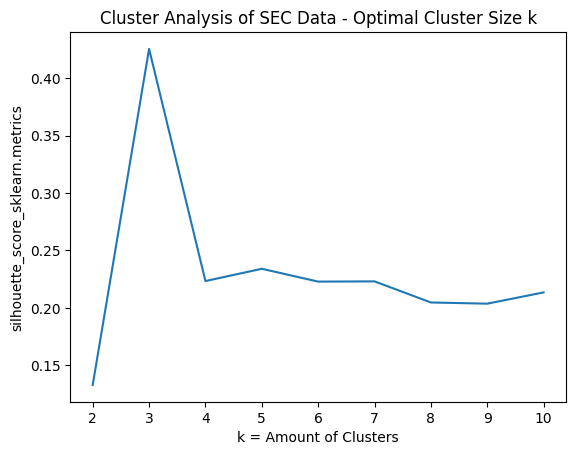

In [7]:
ys = silhouettes
xs = [x for x in range(2, 11)]

plt.plot(xs, ys)
plt.title("Cluster Analysis of SEC Data - Optimal Cluster Size k")
plt.xlabel("k = Amount of Clusters")
plt.ylabel("silhouette_score_sklearn.metrics")
plt.show()


Clusteranalyse durchführen mit k = 3


In [8]:
kmeans_k2 = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=30,
    random_state=42
)

feature_cols = df_scaled.columns

X = df_scaled[feature_cols].values

df_scaled["kmeans_k2"] = kmeans_k2.fit_predict(X)

cluster_centers = (
    pd.DataFrame(kmeans_k2.cluster_centers_, columns=feature_cols)
      .assign(cluster=lambda d: d.index)
)

cluster_centers
#cluster_centers.to_csv('out.csv', index=False)


,amounts.shares,amounts.pricePerShare,filing_count_reportingOwner.name,trades_14d,holding_change_percent,direct_ownership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,reportingOwner.relationship.isOther,high_frequency_trader,high_change_in_holdings,month_sin,month_cos,cluster
0,-0.001983,0.001144,-0.348644,-0.372542,-0.002699,0.664448,0.639352,0.367329,0.255813,0.076897,0.365049,0.584577,7.791675e-03,-2.937323e-02,0
1,489.003346,-0.004575,-0.410643,-0.396900,-0.003509,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,6.245005e-17,1
2,-0.002264,-0.004245,1.293702,1.382375,-0.003504,0.122361,0.436793,0.333556,0.305362,0.491982,0.996970,0.183473,-1.421043e-01,2.396635e-01,2
3,-0.001139,-0.004570,-0.412341,-0.395391,343.515477,1.000000,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,-2.983724e-16,-2.116363e-16,3


In [9]:
df_scaled.groupby("kmeans_k2").size()

kmeans_k2
0    188636
1         1
2     50780
3         2
dtype: int64

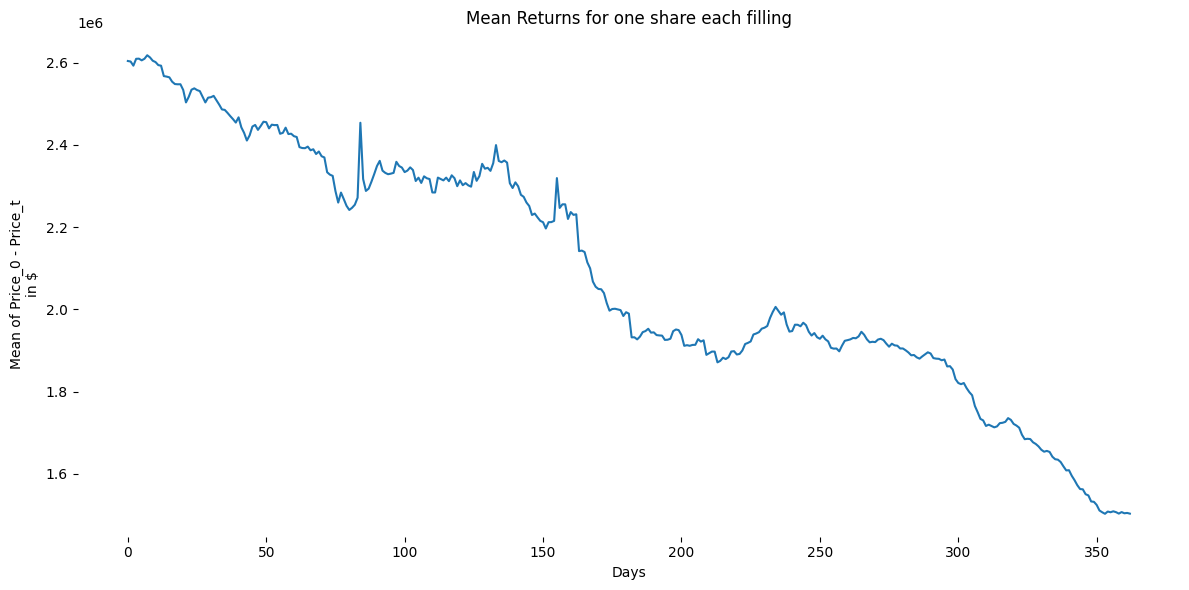

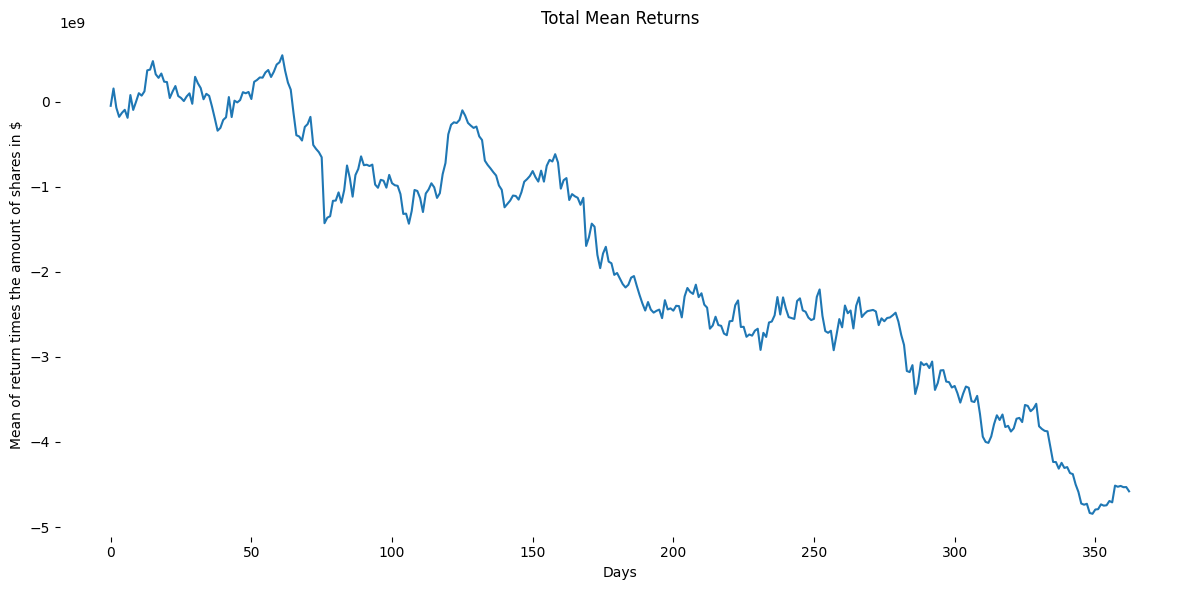

In [14]:
# Mean Returns for each cluster one share each filling
data = pd.read_csv("data/inner_close_sec.csv")
x_0 = data['amounts.pricePerShare'].to_numpy()[:, None]
day_cols = [str(i) for i in range(1, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = Xt - x_0
return_data = pd.DataFrame(return_matrix)
mean_return = return_data.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Mean Returns for one share each filling')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of Price_0 - Price_t\nin $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()


# Total Mean Returns for each cluster: actual return with amount of shares
n = data['amounts.shares'].to_numpy()[:, None]
x_0 = data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(1, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
return_data = pd.DataFrame(return_matrix)
mean_return = return_data.mean()

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(mean_return)
ax.set_title('Total Mean Returns')
ax.set_xlabel('Days')
ax.set_ylabel('Mean of return times the amount of shares in $')

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()
plt.show()


Visualisierung der Cluster

Performance pro cluster vergleichen

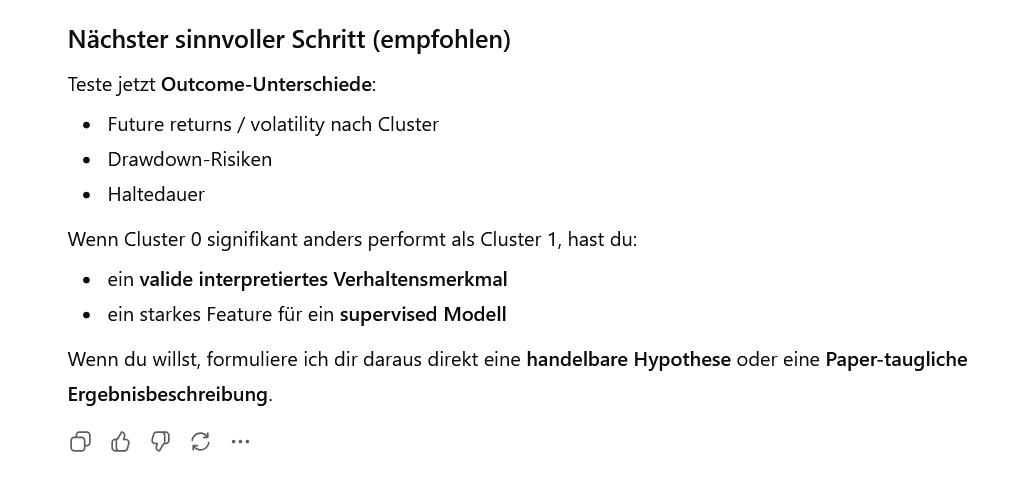

Alternative cluster Algos

preisrohdaten, bzw demeant usw und standardized_relevant_data_uncleaned

erkenntnisse auf targetengeneering anwenden

<Axes: >

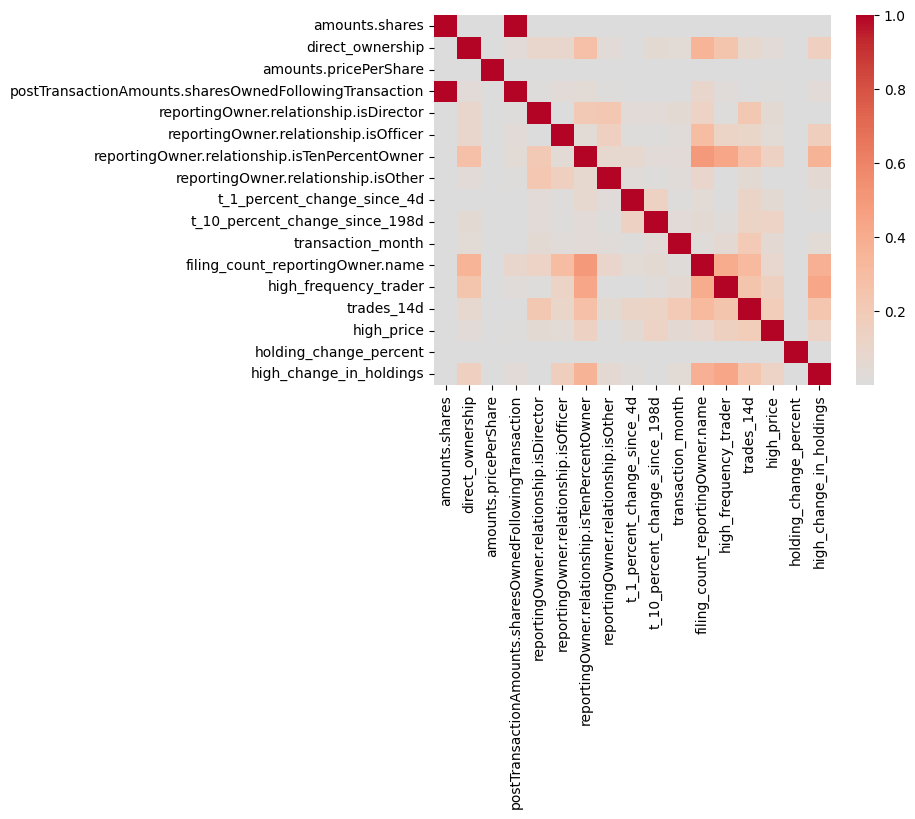

In [ ]:
corr_matrix = standardized_relevant_data_uncleaned.corr(numeric_only=False).abs()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

In [ ]:
# covariance matrix on absolute price, return per stock, absolute return weighted with amount of shares,  demeaned, percent
def plot_heatmap(df, ax, plt_title = "Return Xt - x_0"):
    corr_matrix = df.corr(numeric_only=False).abs()
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax)
    ax.set_title(plt_title)    

day_cols = [str(i) for i in range(364)]
absolute_price_df = pd.DataFrame(all_df_of_close_data[day_cols])

# return per stock: returns for one share each filling
x_0 = data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = data[day_cols].to_numpy()
return_matrix = Xt - x_0
simple_return_df = pd.DataFrame(return_matrix)

# absolute return weighted with amount of shares
n = all_df_of_close_data['amounts.shares'].to_numpy()[:, None]
x_0 = all_df_of_close_data['0'].to_numpy()[:, None]
day_cols = [str(i) for i in range(0, 364)]
Xt = all_df_of_close_data[day_cols].to_numpy()
return_matrix = (Xt - x_0)*n
weighted_return_df = pd.DataFrame(return_matrix)

# demeaned
# with matrix or else warning
abs_mat = all_df_of_close_data[day_cols].to_numpy(dtype=float)
row_mean = np.nanmean(abs_mat, axis=1, keepdims=True)
demean_mat = abs_mat - row_mean
demean_df = pd.DataFrame(demean_mat)

#percent
# calculate percentage since day 0
ref = all_df_of_close_data[day_cols[0]].to_numpy(dtype=float)[:, None]
ref = np.where(ref == 0, np.nan, ref)
percent_mat = (abs_mat - ref) / ref
percent_df = pd.DataFrame(percent_mat)

# plot absolute, demeaned and percentage in one pic
fig, axs = plt.subplots(2, 3, figsize=(12, 12), sharex=True)

plot_heatmap(absolute_price_df,  axs[0, 0], "Covariance of Absolute Price")
plot_heatmap(simple_return_df,   axs[0, 1], "Covariance of Simple Return Xt - x_0")
plot_heatmap(weighted_return_df, axs[0, 2], "Covariance of Weighted Return (Xt - x_0)*n")
plot_heatmap(demean_df,          axs[1, 0], "Covariance of Demeaned Price")
plot_heatmap(percent_df,         axs[1, 1], "Covariance of Percent (abs_mat - ref)/ref")


plt.tight_layout()
#plt.savefig('exports/descriptive_random_state_69.png', dpi=500)
plt.show()


## SNIPPET 4.1 BASE CLUSTERING  

MACHINE LEARNING FOR
ASSET MANAGERS
Marcos M. López de Prado

In [ ]:
x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()

In [2]:
def clusterKMeansBase(corr0, maxNumClusters=10, n_init=10):
    x, silh=((1-corr0.fillna(0))/2.)**.5, pd.Series()  # observation matrix
    for init in range(n_init):
        for i in xrange(2, maxNumClusters+1):
            kmeans_=KMeans(n_clusters=i, n_jobs=1, n_init=1)
            kmeans_=kmeans_.fit(x)
            silh_=silhouette_samples(x, kmeans_.labels_)
            stat=(silh_.mean()/silh_.std(), silh.mean()/silh.std())
            if np.isnan(stat[1]) or stat[0]>stat[1]:
                silh, kmeans=silh_, kmeans_
    newIdx=np.argsort(kmeans.labels_)
    corr1=corr0.iloc[newIdx]  # reorder rows

    corr1=corr1.iloc[:,newIdx]  # reorder columns
    clstrs={i:corr0.columns[np.where(kmeans.labels_==i)[0]].tolist()\
            for i in np.unique(kmeans.labels_)}  # cluster members
    silh=pd.Series(silh, index=x.index)
    return corr1, clstrs, silh
